In [26]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline 

import pickle


In [5]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("dataset.csv")

# Show first rows
df.head()

,Production_tons_per_day,Temperature_C,Humidity_%,Pollution_AQI
0,43.708611,24.023505,88.459058,163.682724
1,95.564288,21.601268,NaN,624.929869
2,75.879455,29.489064,86.859099,401.361744
3,63.879264,20.199385,52.120645,357.196261
4,24.041678,21.695323,30.605424,82.070293


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (6500, 4)

Columns:
Index(['Production_tons_per_day', 'Temperature_C', 'Humidity_%',
       'Pollution_AQI'],
      dtype='object')

Data Types:
Production_tons_per_day    float64
Temperature_C              float64
Humidity_%                 float64
Pollution_AQI              float64
dtype: object


In [7]:
df.isnull().sum()

Production_tons_per_day    195
Temperature_C              195
Humidity_%                 195
Pollution_AQI              195
dtype: int64

In [8]:
df.describe()

,Production_tons_per_day,Temperature_C,Humidity_%,Pollution_AQI
count,6305.000000,6305.000000,6305.000000,6305.000000
mean,54.575076,29.889858,60.347927,301.663631
std,26.004059,5.731098,17.369463,227.607178
min,10.001047,20.001057,30.015147,-44.087823
25%,31.912034,24.987516,45.261572,116.061709
50%,54.628816,29.771223,60.489438,261.753750
75%,76.751572,34.854617,75.448939,457.867320
max,99.974591,39.993464,89.995490,2495.968925


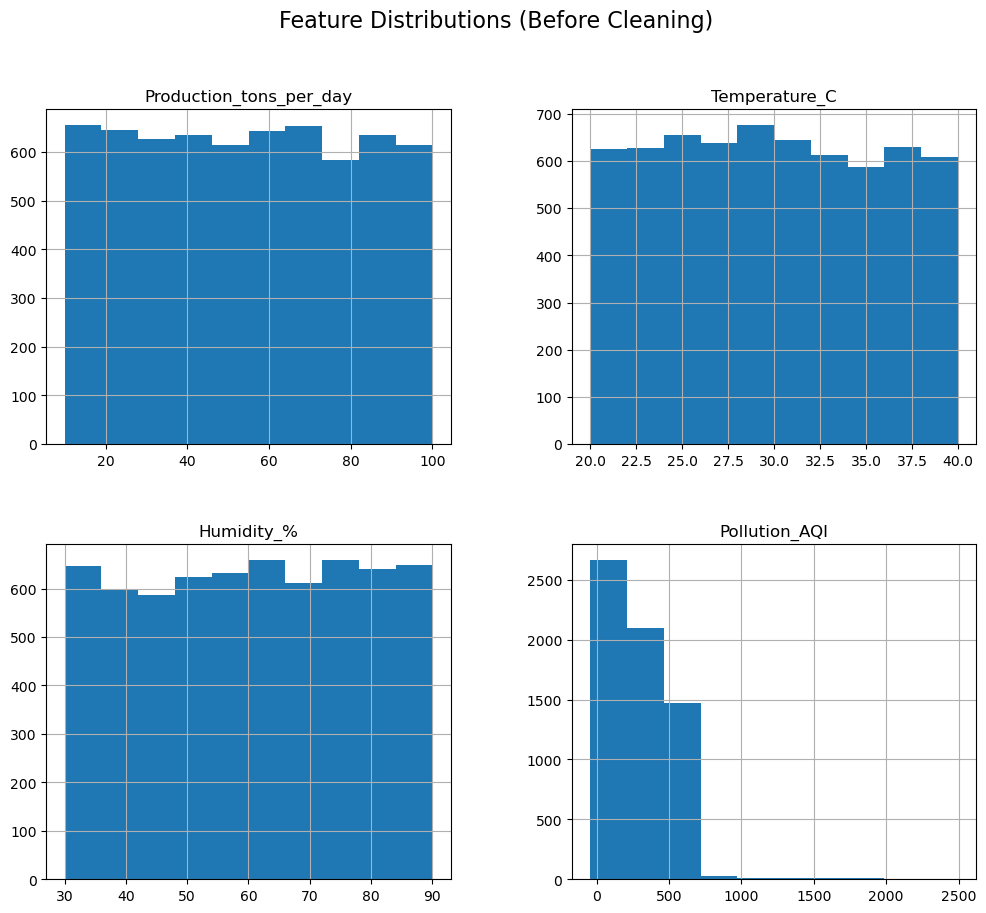

In [9]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions (Before Cleaning)", fontsize=16)
plt.show()

In [13]:
cols = [
    "Production_tons_per_day",
    "Temperature_C",
    "Humidity_%",
    "Pollution_AQI"
]

for col in cols:
    # Drop nulls before calculating
    clean_data = df[col].dropna()

    Q1 = clean_data.quantile(0.25)
    Q3 = clean_data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Production_tons_per_day: 0 outliers
Temperature_C: 0 outliers
Humidity_%: 0 outliers
Pollution_AQI: 46 outliers


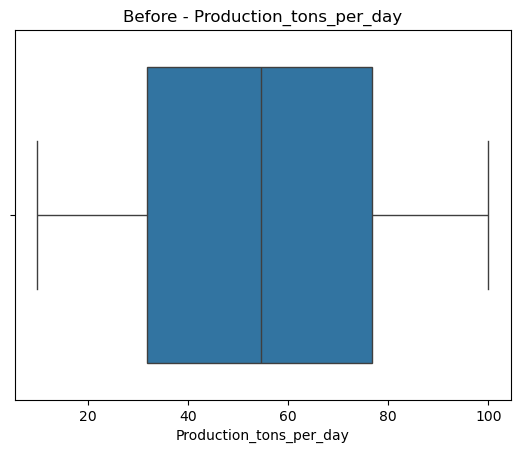

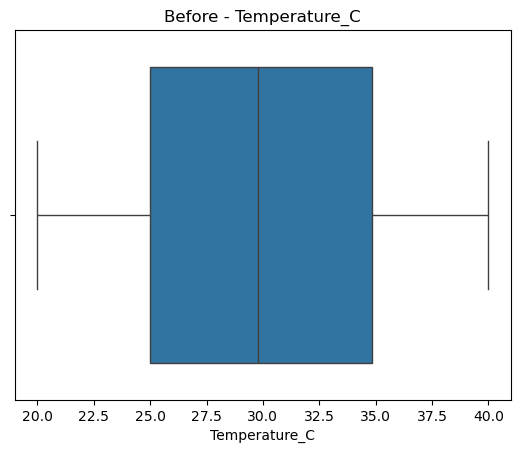

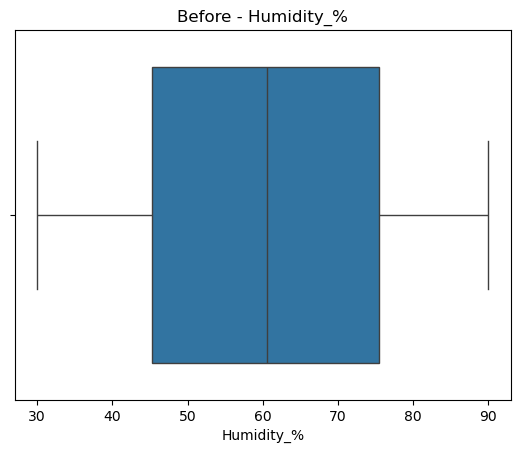

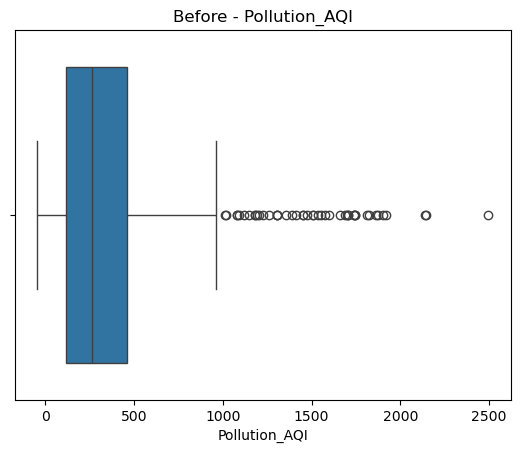

In [14]:
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Before - {col}")
    plt.show()

In [15]:
df_clean = df.copy()

print("Filling Missing Values...")

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        
        if abs(df_clean[col].skew()) > 0.5:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

df_clean.isnull().sum()

Filling Missing Values...


Production_tons_per_day    0
Temperature_C              0
Humidity_%                 0
Pollution_AQI              0
dtype: int64

In [16]:
for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = np.clip(df_clean[col], lower, upper)

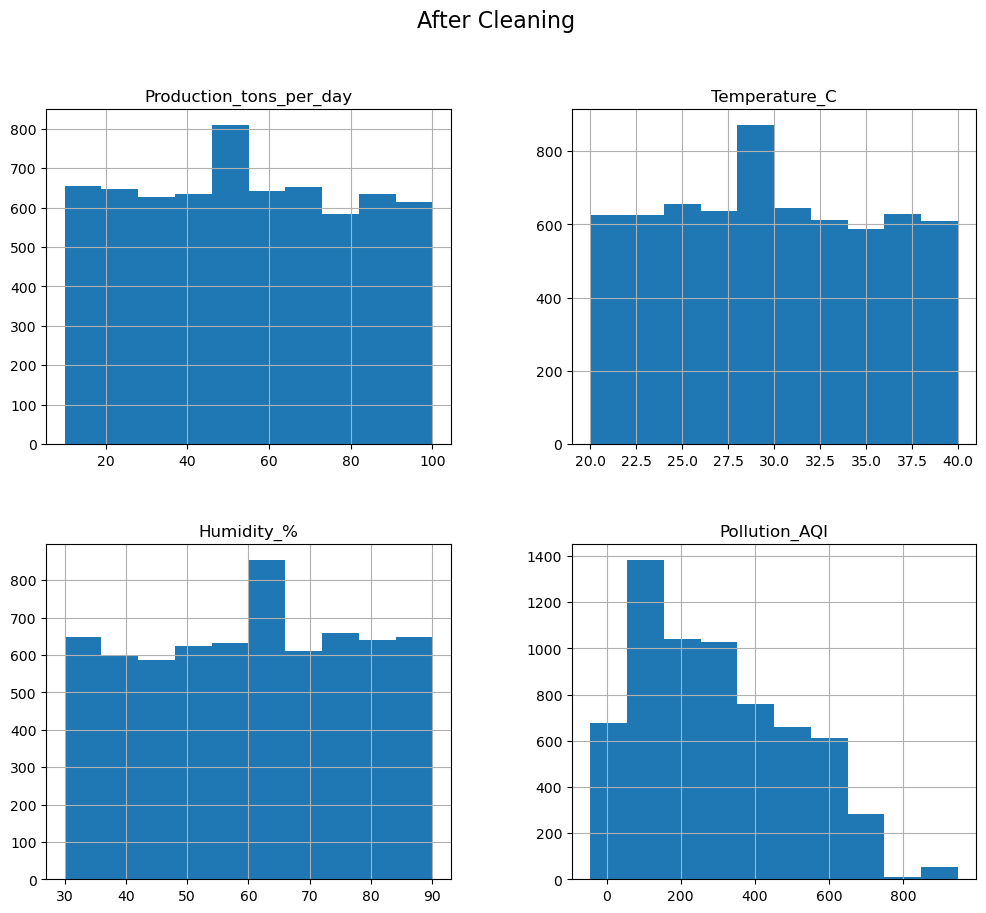

In [17]:
df_clean.hist(figsize=(12,10))
plt.suptitle("After Cleaning", fontsize=16)
plt.show()

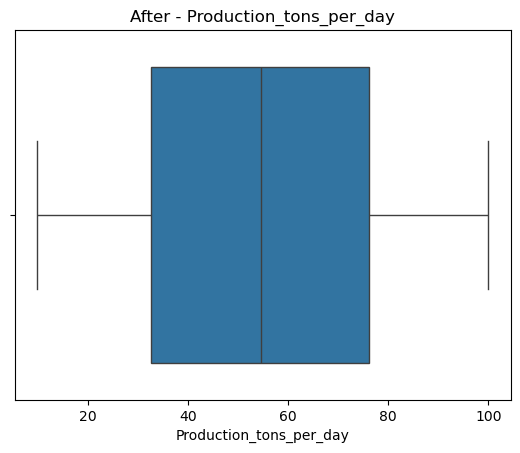

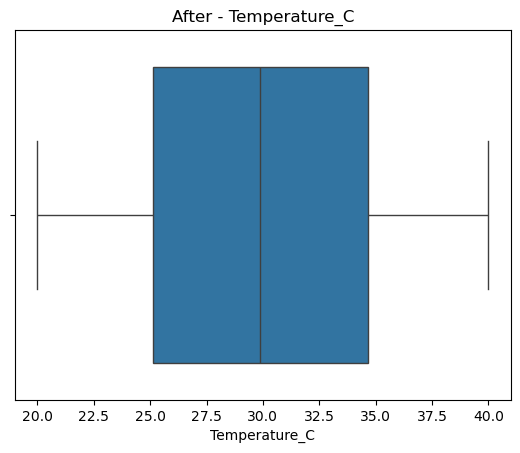

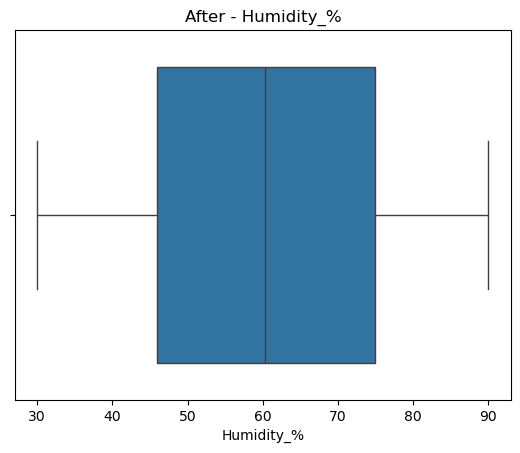

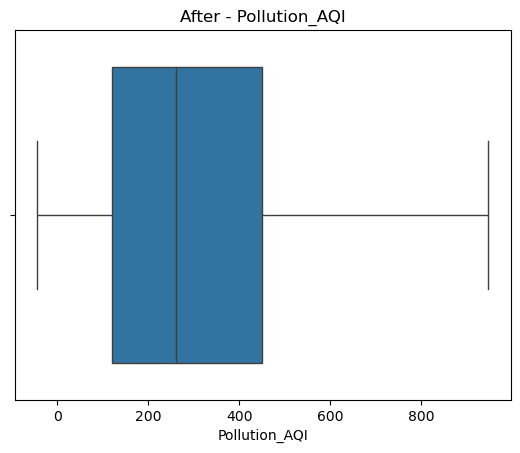

In [18]:
for col in cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"After - {col}")
    plt.show()

In [19]:
df_clean.describe()

,Production_tons_per_day,Temperature_C,Humidity_%,Pollution_AQI
count,6500.000000,6500.000000,6500.000000,6500.000000
mean,54.575076,29.889858,60.347927,296.412205
std,25.610967,5.644463,17.106897,204.796627
min,10.001047,20.001057,30.015147,-44.087823
25%,32.585343,25.107580,45.868252,119.800874
50%,54.575076,29.889858,60.347927,261.753750
75%,76.094672,34.646785,74.956746,451.145068
max,99.974591,39.993464,89.995490,948.161359


In [20]:
df_clean.to_csv("final_data.csv", index=False)
print("Saved ✅")

Saved ✅


In [72]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
# Load dataset
df = pd.read_csv("final_data.csv")

# Fill missing values with mean
df = df.fillna(df.mean(numeric_only=True))

# Define input features (X) and target (y)
X = df[["Production_tons_per_day", "Temperature_C", "Humidity_%"]]
y = df["Pollution_AQI"]

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [74]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
# Train model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [77]:
# Predict on test data
y_pred = model.predict(X_test)

In [50]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('poly', PolynomialFeatures()),
                ('ridge', Ridge(alpha=5.0))])

In [78]:
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n🔹 MODEL PERFORMANCE")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


🔹 MODEL PERFORMANCE
MAE: 38.035604956360764
MSE: 7830.694705336355
RMSE: 88.49121258823587
R2 Score: 0.822009994390833


In [79]:
# Compare train vs test score
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("\n🔹 OVERFITTING CHECK")
print("Train R2:", train_score)
print("Test R2:", test_score)


🔹 OVERFITTING CHECK
Train R2: 0.8655601275845997
Test R2: 0.822009994390833


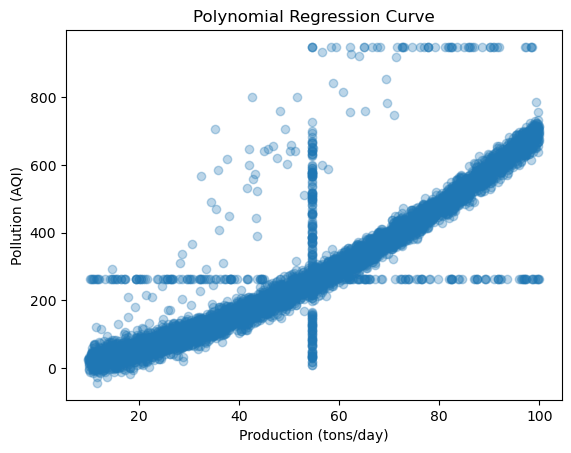

In [80]:
# Create smooth production values for curve
prod_range = np.linspace(
    X["Production_tons_per_day"].min(),
    X["Production_tons_per_day"].max(),
    500
)

# Create new dataset for plotting
X_plot = pd.DataFrame({
    "Production_tons_per_day": prod_range,
    "Temperature_C": X["Temperature_C"].mean(),
    "Humidity_%": X["Humidity_%"].mean()
})

# Predict curve values
y_plot = model.predict(X_plot)

# Plot graph
plt.scatter(X["Production_tons_per_day"], y, alpha=0.3)
plt.plot(prod_range, y_plot)

plt.xlabel("Production (tons/day)")
plt.ylabel("Pollution (AQI)")
plt.title("Polynomial Regression Curve")
plt.show()

In [81]:
# Function to categorize pollution level
def categorize_aqi(aqi):
    if aqi <= 150:
        return "LOW"
    elif aqi <= 300:
        return "MEDIUM"
    else:
        return "HIGH"

In [82]:
# Show some predictions
print("\n🔹 SAMPLE OUTPUT")

for i in range(5):
    value = y_pred[i]
    category = categorize_aqi(value)
    
    print(f"AQI: {value:.2f} → {category}")


🔹 SAMPLE OUTPUT
AQI: 444.11 → HIGH
AQI: 158.67 → MEDIUM
AQI: 94.60 → LOW
AQI: 350.15 → HIGH
AQI: 261.00 → MEDIUM


In [83]:
# Save trained model
with open("pollution_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\n✅ Model saved as pollution_model.pkl")


✅ Model saved as pollution_model.pkl
